In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, std_dev, nominal_value
from uncertainties.unumpy import nominal_values, std_devs, uarray

# Create calibrated Spectrum 
from pyspectrum.core import Spectrum
from pyspectrum.io import TimeChannelParser
from pyspectrum.calibration.models.hpge_fwhm_model import StandardHPGeFWHMModel
from pyspectrum.calibration import AxisCalibration, ResolutionCalibration

# identification of peaks
from pyspectrum.identification import Convolution
from pyspectrum.identification.snr import SNRFinder
from pyspectrum.identification.kernels.mexican_hat import gaussian_2_dev

# load the spectrum

In [2]:
path = '../Library/Doppler_broadening_Spectrum.txt'
df_spectrum = pd.read_csv(path, sep=' ', skiprows=5, names=['time','channel','flag'], usecols=[0,1,2])


# known calibration
energy_calib_poly = np.poly1d([0.0408976444, 0.0822321508])
# known resolution
energy_resolution = 1.05
estimated_FWHM = StandardHPGeFWHMModel().generator((0, energy_resolution/511**0.5, 0))


energy_calib = AxisCalibration(func=energy_calib_poly, name="energy")
res_calib = ResolutionCalibration(func=estimated_FWHM)

spectrum  = TimeChannelParser.from_file(path, energy_calibration=energy_calib, fwhm_calibration=res_calib,
                                        num_of_channels=16384, chunk_size=int(10000),
                                        sep=' ', skiprows=5, names=['time','channel','flag'], usecols=[0,1,2])

(300.0, 700.0)

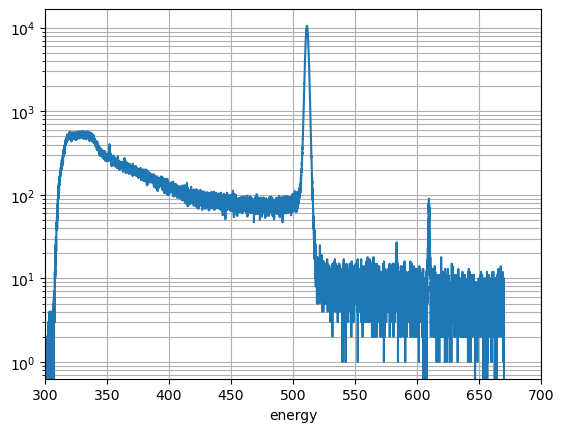

In [3]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.xlim([300,700])

# find the domains above snr

In [4]:
conv = Convolution(resolution=res_calib.apply, kernel=gaussian_2_dev, window_fwhm=3)
finder = SNRFinder(convolution=conv, n_sigma_signal_threshold=4, n_sigma_bg_threshold=2.0, persistence_factor=0.5)

specific domain (the annihilation peak)

In [5]:
annihilation_domain = finder.domain(spectrum, 511.0)
(spectrum.axis[annihilation_domain.start], spectrum.axis[annihilation_domain.stop])

(505.24993577960004, 519.0324419424)

convert to Peak

In [6]:
annihilation_peak = annihilation_domain.to_peak()

Peak can be has builtin method such as background subtraction, center and fwhm estimation

In [7]:
annihilation_peak.estimated_center, annihilation_peak.estimated_resolution

(511.19857598225093, 2.658346886000004)

Text(0, 0.5, 'counts')

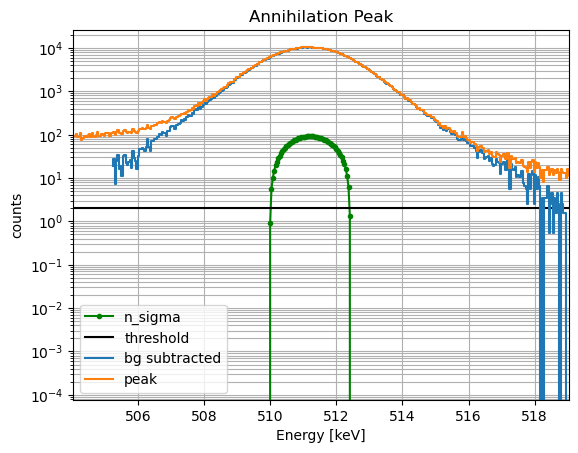

In [15]:
_,_, n_sigma = conv.apply(spectrum.axis, spectrum.counts)

plt.plot(spectrum.axis, n_sigma, label='n_sigma', marker='.', color='green')
plt.axhline(finder.n_sigma_bg_threshold, color='black', label='threshold')
plt.xlim([spectrum.axis[annihilation_domain.start-30],spectrum.axis[annihilation_domain.stop]])
plt.step(annihilation_peak.channel, nominal_values(annihilation_peak.subtract_background()), label='bg subtracted')
spectrum.plot.step(label='peak', yscale='log')
plt.legend()

plt.grid(True, which='both')
plt.title('Annihilation Peak')
plt.xlabel('Energy [keV]')
plt.ylabel('counts')

# Domains identification

In [17]:
conv = Convolution(resolution=res_calib.apply, kernel=gaussian_2_dev, window_fwhm=4)
finder = SNRFinder(convolution=conv, n_sigma_signal_threshold=4, n_sigma_bg_threshold=2, persistence_factor=0.5)
domains = finder.find(spectrum)

8566 8647
12352 12689
14223 14307
14848 14957


Text(0, 0.5, 'counts')

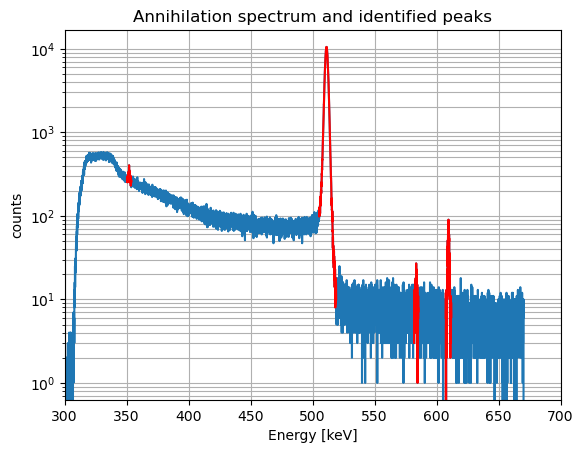

In [18]:
spectrum.plot(yscale='log')
for domain in domains:
    domain.plot(color='red')
plt.xlim([300, 700])
plt.grid(True, which='both')
plt.title('Annihilation spectrum and identified peaks')
plt.xlabel('Energy [keV]')
plt.ylabel('counts')

example how to use a domains - 

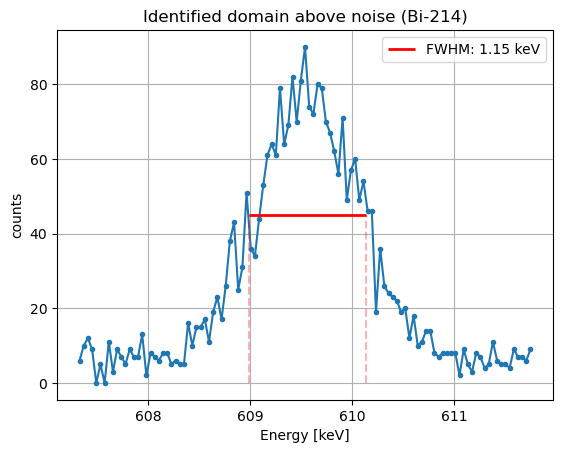

In [19]:
# 1. Calculations
mean_energy = (domains[-1].data.energy * domains[-1].data).sum() / domains[-1].data.sum()
fwhm = domains[-1].local_resolution
max_counts = domains[-1].data.max()
half_max = max_counts / 2

# 2. Plotting
domains[-1].plot(marker='.')
plt.grid(True, which='both')
plt.title('Identified domain above noise (Bi-214)')
plt.xlabel('Energy [keV]')
plt.ylabel('counts')

# 3. Add the FWHM Bar
# xmin and xmax define the edges of the resolution bar
plt.hlines(y=half_max, 
           xmin=mean_energy - (fwhm / 2), 
           xmax=mean_energy + (fwhm / 2), 
           colors='r', linestyles='-', lw=2, label=f'FWHM: {fwhm:.2f} keV')

# Optional: Add vertical dashed lines to "anchor" the bar to the axis
plt.vlines(x=[mean_energy - (fwhm / 2), mean_energy + (fwhm / 2)], 
           ymin=0, ymax=half_max, colors='r', linestyles='--', alpha=0.3)

plt.legend()
plt.show()

In [20]:
print("peaks centers:")
for domain in domains:
    print(spectrum.axis_calib.apply((domain*domain.indices/domain.sum()).sum()))

peaks centers:
352.0351390195787
511.1580479867833
583.4805633812313
609.5594859403524
